# Paquetes

In [58]:
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt 
from tqdm import tqdm 
from robolib.DoublePendulum import DoublePendulum
import spatialmath as sm

# Declaracion de robot

In [59]:
dp = rtb.DHRobot(
    [
        rtb.RevoluteDH(a=0.2,m=1.5,
            r=np.array([-0.1, 0, 0]),           #Posicion del COM respecto de las ternas 
            I=np.array([0,0,0,0,0,0,0,0,1e-3]), #Momento de inercia respecto del COM
            B=1e-4, G=100, Jm = 1e-5),          #Viscosidad, GearRatio, Inercia del motor                     
        rtb.RevoluteDH(a=0.2,m=1,
            r=np.array([-0.1, 0, 0]),
            I=np.array([0,0,0,0,0,0,0,0,1e-4]),
            B=1e-4, G=100, Jm = 1e-5)                      
    ],
    gravity = np.array([0, -9.8, 0]), # Ojo con el signo, la gravedad va hacia abajo con signo positivo
    name="dp")

print(dp)
print(dp.dynamics())

DHRobot: dp, 2 joints (RR), dynamics, standard DH parameters
┌─────┬────┬─────┬──────┐
│ θⱼ  │ dⱼ │ aⱼ  │  ⍺ⱼ  │
├─────┼────┼─────┼──────┤
│  q1 │  0 │ 0.2 │ 0.0° │
│  q2 │  0 │ 0.2 │ 0.0° │
└─────┴────┴─────┴──────┘

┌──┬──┐
└──┴──┘

┌───────┬──────┬──────────────┬─────────────────────────────┬────────┬─────────┬────────┬──────┐
│   j   │  m   │      r       │              I              │   Jm   │    B    │   Tc   │  G   │
├───────┼──────┼──────────────┼─────────────────────────────┼────────┼─────────┼────────┼──────┤
│ link1 │  1.5 │ -0.1,  0,  0 │  0,  0,  0.001,  0,  0,  0  │  1e-05 │  0.0001 │  0,  0 │  100 │
│ link2 │  1   │ -0.1,  0,  0 │  0,  0,  0.0001,  0,  0,  0 │  1e-05 │  0.0001 │  0,  0 │  100 │
└───────┴──────┴──────────────┴─────────────────────────────┴────────┴─────────┴────────┴──────┘

None


# Simulacion

In [60]:
solver_kwargs = {
    'rtol': 1e-4     # Tolerancia relativa
    #'atol': 1e-8     # Tolerancia absoluta
    #'max_step': 0.1   # Tamaño máximo del paso de integración
}

## Funciones Utiles

In [61]:
def plot_dinamica(tg, dp):
    # Plot de varaibles articulares
    plt.figure()
    plt.plot(tg.t,tg.q * 180/np.pi)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("q [grados]")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(tg.t,tg.qd * 180/np.pi)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("qd [grados/s]")
    plt.grid()
    plt.show()


    #Plot trayectoria
    plt.figure(figsize=(5,5))
    trayectoria = dp.fkine(tg.q)
    plt.plot(trayectoria.t[:,0],trayectoria.t[:,1],'b-',linewidth=1,label='real')
    plt.legend(loc='upper right')
    plt.xlabel('X [m]')
    plt.ylabel('Y [m]')
    plt.grid()
    plt.title('Trayectoria realizada')
    plt.axis([-0.4, 0.4, -0.4, 0.4])	
    plt.tight_layout()



## Condicion inicial con rozamiento

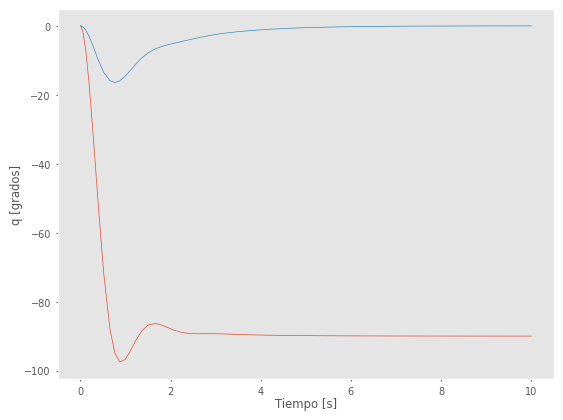

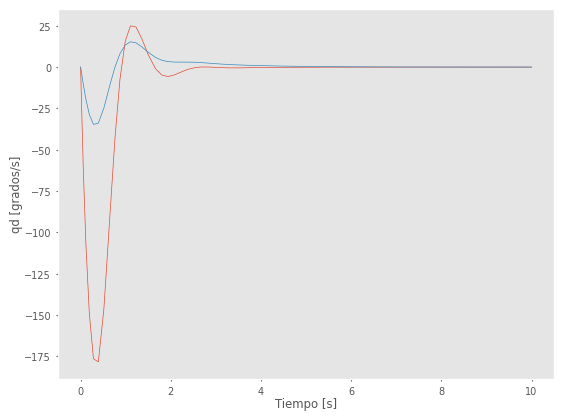

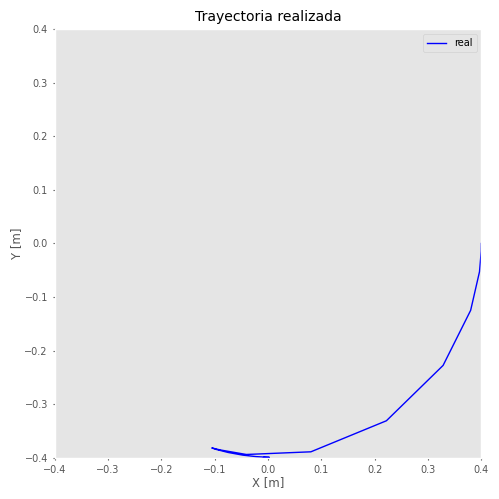

In [62]:
q_ini = np.array([0,0])
qp_ini = np.array([0,0])

tg = dp.nofriction(coulomb=True, viscous=False).fdyn(10, q_ini, qd0 = qp_ini, solver_args= solver_kwargs)

plot_dinamica(tg, dp)


## Poco rozamiento

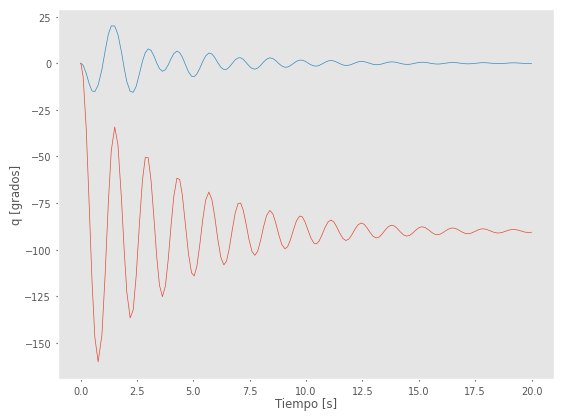

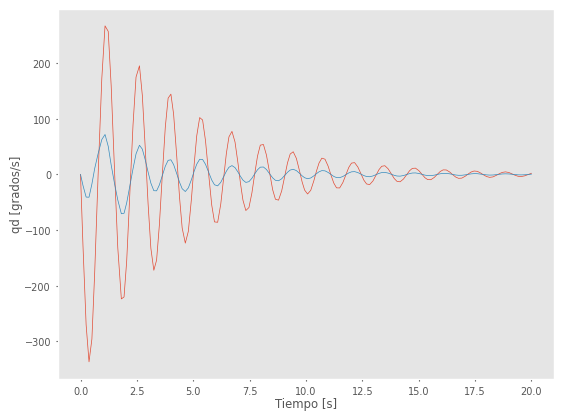

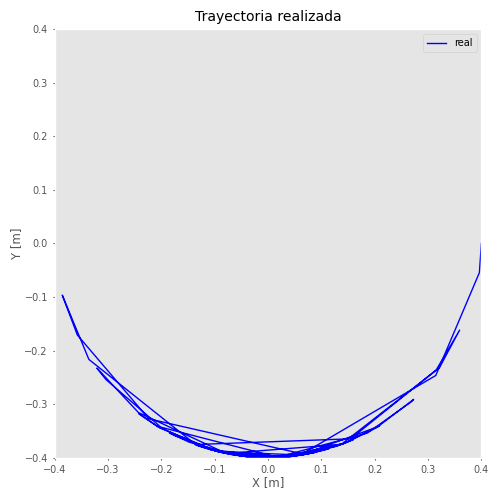

In [63]:
#Modifico la viscosidad del modelo
dp.links[0].B = 1e-5
dp.links[1].B = 1e-5

q_ini = np.array([0,0])
qp_ini = np.array([0,0])

tg = dp.nofriction(coulomb=True, viscous=False).fdyn(20, q_ini, qd0 = qp_ini, solver_args= solver_kwargs)

plot_dinamica(tg, dp)

## Condicion inicial sin rozamiento (caotico)

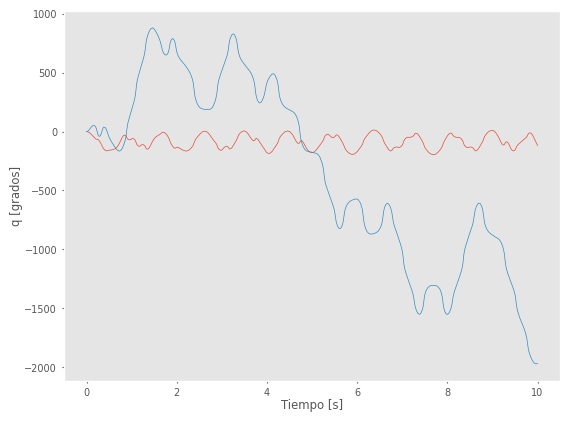

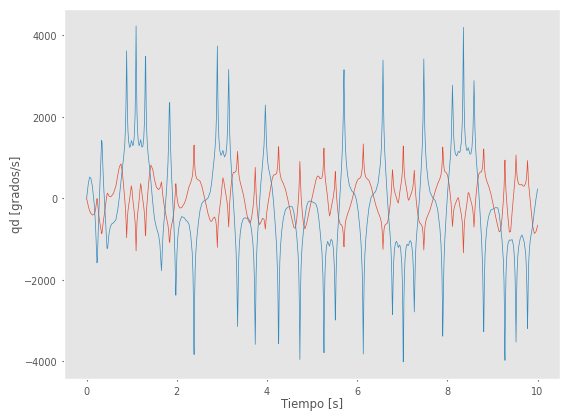

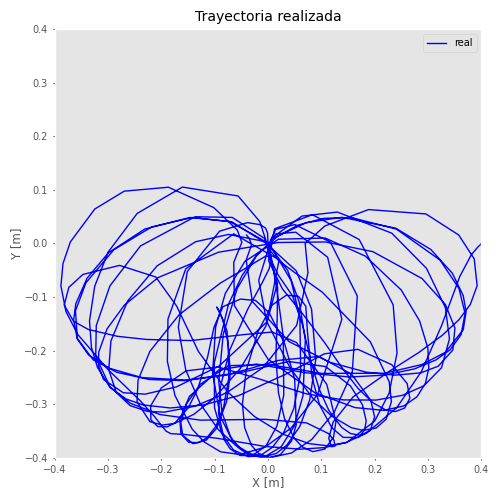

In [64]:
#Inercia nula
dp.links[0].Jm = 0
dp.links[1].Jm = 0

q_ini = np.array([0,0])
qp_ini = np.array([0,0])

tg = dp.nofriction(coulomb=True, viscous=True).fdyn(10, q_ini, qd0 = qp_ini, solver_args= solver_kwargs)

plot_dinamica(tg, dp)


## Equilibrio Inestable

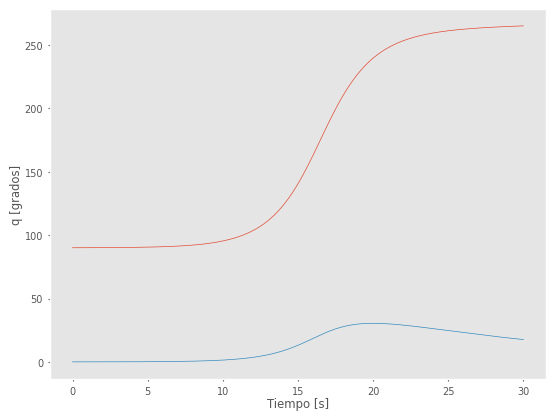

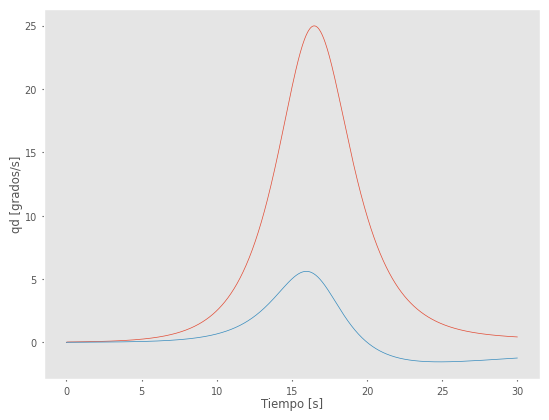

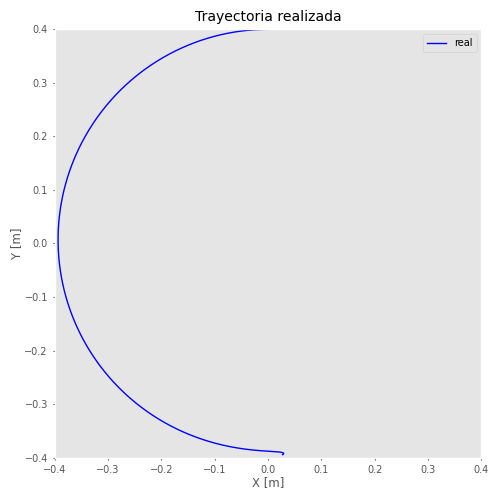

In [65]:
#Modifico la viscosidad del modelo
dp.links[0].B = 1e-3
dp.links[1].B = 1e-3
dp.links[0].Jm = 1e-5
dp.links[1].Jm = 1e-5

q_ini = np.array([(np.pi/2)+0.001,0])
qp_ini = np.array([0,0])

tg = dp.nofriction(coulomb=True, viscous=False).fdyn(30, q_ini, qd0 = qp_ini, solver_args= solver_kwargs)

plot_dinamica(tg, dp)


# Control PD

In [66]:
def calc_pd(omega_n, print_results=False):
    # Calculo las ganancias del control PD
    q_test = np.array([0, np.pi/2])  # Caso promedio de inercias 
    mbar = dp.inertia(q_test)

    B = np.diag(np.r_[dp.links[0].B, dp.links[1].B])
    N = np.diag(np.r_[dp.links[0].G, dp.links[1].G])

    Km = 1 
    Jef = np.array([[mbar[0,0], 0],
                    [0, mbar[1,1]]])
    Bef = B @ N**2 


    if np.ndim(omega_n) == 1:
        Wn = np.diag(omega_n)
    else:
        Wn = omega_n


    inv_NKm = np.linalg.inv(Km * N)
    Kp = (Wn @ Wn) @ Jef @ inv_NKm
    dentro_raiz = Km * N @ Kp @ Jef

    raiz_matricial = np.diag(np.sqrt(np.diag(dentro_raiz)))

    # Kd = (2 * Raiz - Bef) @ (Km*N)^-1
    Kd = (2 * raiz_matricial - Bef) @ inv_NKm
    

    
    if print_results:
        print(f'Kp = \n{Kp}')
        print(f'Kd = \n{Kd}')

        print(f'Tiempo de muestreo = {dp.Ts*1000:.2f} ms')
        print(f'Pulsación de muestreo (ws) = {2*np.pi/dp.Ts:.2f} rad/s')
        print(f'Pulsación límite por muestreo = {2*np.pi/dp.Ts/20:.2f} rad/s')

    return Kp, Kd



Generacion del modelo y trayectoria arbitraria

In [67]:
dp = DoublePendulum()

# Actualizo algunos términos de la dinámica
dp.links[0].Jm = 1e-5
dp.links[1].Jm = 1e-5
dp.links[0].B = 1e-4
dp.links[1].B = 1e-4
dp.links[0].G = 100
dp.links[1].G = 100

print(dp)
print(dp.dynamics())

# Determino una trayectoria de referencia
q_dest = np.array([[-np.pi/2, 0.0],[0,np.pi/4],[0,-np.pi/4],[0,0],[0,0]])   #Puntos de la trayectoria 
Tj = np.array([1, 0.5,1,1,1 ])                                              #Tiempos objetivo
POSES_dest = dp.fkine(q_dest)

# Trayectoria JOINT
dp.jtraj(q_dest,Tj);
# Trayectoria CARTESIANA
#dp.ctraj(POSES_dest,Tj);

DHRobot: DoublePendulum, 2 joints (RR), dynamics, standard DH parameters
┌─────┬────┬─────┬──────┐
│ θⱼ  │ dⱼ │ aⱼ  │  ⍺ⱼ  │
├─────┼────┼─────┼──────┤
│  q1 │  0 │ 0.2 │ 0.0° │
│  q2 │  0 │ 0.2 │ 0.0° │
└─────┴────┴─────┴──────┘

┌──┬──┐
└──┴──┘

┌───────┬──────┬──────────────┬─────────────────────────────┬────────┬─────────┬────────┬──────┐
│   j   │  m   │      r       │              I              │   Jm   │    B    │   Tc   │  G   │
├───────┼──────┼──────────────┼─────────────────────────────┼────────┼─────────┼────────┼──────┤
│ link1 │  1   │ -0.1,  0,  0 │  0,  0,  0.001,  0,  0,  0  │  1e-05 │  0.0001 │  0,  0 │  100 │
│ link2 │  1.5 │ -0.1,  0,  0 │  0,  0,  0.0001,  0,  0,  0 │  1e-05 │  0.0001 │  0,  0 │  100 │
└───────┴──────┴──────────────┴─────────────────────────────┴────────┴─────────┴────────┴──────┘

None


Calculo ganancias de control PD

In [68]:
Kp, Kd = calc_pd(omega_n=[150, 100],print_results=True)

Kp = 
[[41.8725  0.    ]
 [ 0.     11.51  ]]
Kd = 
[[0.5483 0.    ]
 [0.     0.2202]]
Tiempo de muestreo = 1.00 ms
Pulsación de muestreo (ws) = 6283.19 rad/s
Pulsación límite por muestreo = 314.16 rad/s


Simulacion del control

100%|██████████| 3699/3699 [00:17<00:00, 206.14it/s]


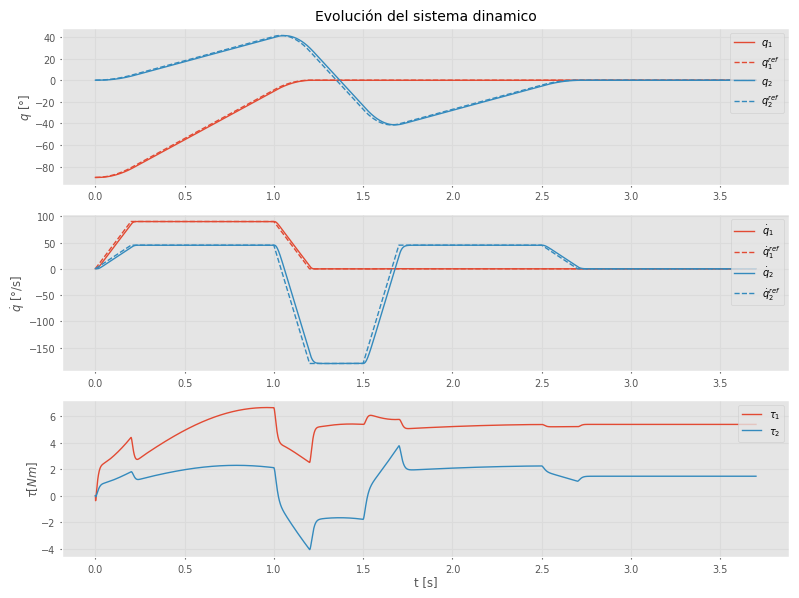

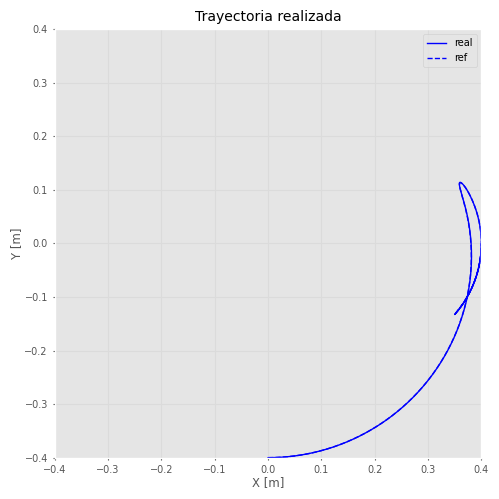

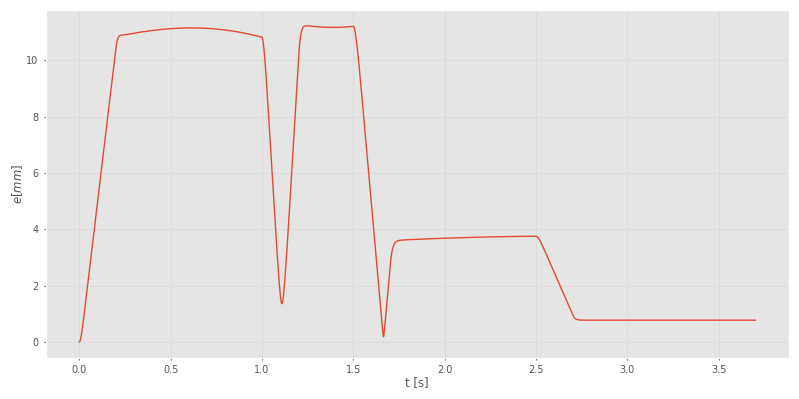

In [69]:
# Inicializo vectores para simulacion
u = np.zeros_like(dp.q_ref)
q = np.zeros_like(dp.q_ref)
qd = np.zeros_like(dp.qd_ref)

# La condición inicial sale de la primera muestra de las referencias
q[0,:] = dp.q_ref[0,:]
qd[0,:] = dp.qd_ref[0,:]

#Saturacion
umax = 10

#Deberia agregar el ZOH

# Realizo la simulación 
for idx in tqdm(range(1,len(dp.t_ref))):
  N = np.diag(np.r_[dp.links[0].G,dp.links[1].G])
  # Calculo la ley de control PD
  u[idx,:] = N @ (Kp @ (dp.q_ref[idx]-q[idx-1]) + Kd @ (-qd[idx-1]))
  # Aplico la saturación en la acción de control
  u[idx,:] = np.clip(u[idx,:],-umax,umax)

  tg = dp.nofriction(coulomb=True, viscous=False).fdyn(dp.Ts, q[idx-1], qd0=qd[idx-1], Q=lambda r, t, q, qd: u[idx], solver_args=solver_kwargs)
  q[idx] = tg.q[-1,:]
  qd[idx] = tg.qd[-1,:]


dp.plot_sim(dp.t_ref,q,qd,dp.t_ref,u)



Animacion

In [70]:
dp.animate_robot(q,frame_rate=12)

# Control PID

In [71]:
"""
def calc_pd(omega_n, Ti,print_results=False):
    # Calculo las ganancias del control PD
    q_test = np.array([0,np.pi/2])  # Caso promedio de inercias 
    mbar = dp.inertia(q_test)

    B = np.diag(np.r_[dp.links[0].B,dp.links[1].B])
    N = np.diag(np.r_[dp.links[0].G,dp.links[1].G])

    Km = 1 
    Jef = np.array([[mbar[0,0],0],[0,mbar[1,1]]])
    Bef = B @ N**2 

    Kp = omega_n**2 * Jef @ np.linalg.inv(Km*N)
    Kd = (2*np.sqrt(Km*N@Kp@Jef)-Bef) @ np.linalg.inv(Km*N)
    Ki = Kp/Ti
    if print_results:
        print(f'Kp = {Kp}')
        print(f'Kd = {Kd}')
        print(f'Ki = {Ki}')
        print(f'Tiempo de muestreo = {dp.Ts*1000:.2f} ms')
        print(f'Pulsación de muestreo (ws) = {2*np.pi/dp.Ts:.2f} rad/s')
        print(f'Pulsación límite por muestreo = {2*np.pi/dp.Ts/20:.2f} rad/s')

    return Kp, Kd, Ki

"""

def calc_pd(omega_n, Ti, print_results=False):

    omega_n = np.atleast_1d(omega_n)
    Ti = np.atleast_1d(Ti)

    if omega_n.size == 1:
        omega_n = np.repeat(omega_n, 2)

    if Ti.size == 1:
        Ti = np.repeat(Ti, 2)

    Omega = np.diag(omega_n)
    Ti_mat = np.diag(Ti)

    # Calculo las ganancias del control PD
    q_test = np.array([0, np.pi/2])
    mbar = dp.inertia(q_test)

    B = np.diag(np.r_[dp.links[0].B, dp.links[1].B])
    N = np.diag(np.r_[dp.links[0].G, dp.links[1].G])

    Km = 1

    Jef = np.diag([mbar[0,0], mbar[1,1]])
    Bef = B @ N**2

    Kp = Omega**2 @ Jef @ np.linalg.inv(Km * N)

    Kd = (
        2 * np.sqrt(Km * N @ Kp @ Jef)
        - Bef
    ) @ np.linalg.inv(Km * N)

    Ki = Kp @ np.linalg.inv(Ti_mat)

    if print_results:
        print(f'Kp = {Kp}')
        print(f'Kd = {Kd}')
        print(f'Ki = {Ki}')
        print(f'Tiempo de muestreo = {dp.Ts*1000:.2f} ms')
        print(f'Pulsación de muestreo (ws) = {2*np.pi/dp.Ts:.2f} rad/s')
        print(f'Pulsación límite por muestreo = {2*np.pi/dp.Ts/20:.2f} rad/s')

    return Kp, Kd, Ki



In [72]:
Kp, Kd, Ki = calc_pd(omega_n = [150, 100], Ti = [100e-3, 100e-3], print_results=True)

Kp = [[41.8725  0.    ]
 [ 0.     11.51  ]]
Kd = [[0.5483 0.    ]
 [0.     0.2202]]
Ki = [[418.725   0.   ]
 [  0.    115.1  ]]
Tiempo de muestreo = 1.00 ms
Pulsación de muestreo (ws) = 6283.19 rad/s
Pulsación límite por muestreo = 314.16 rad/s


100%|██████████| 3699/3699 [00:17<00:00, 215.39it/s]


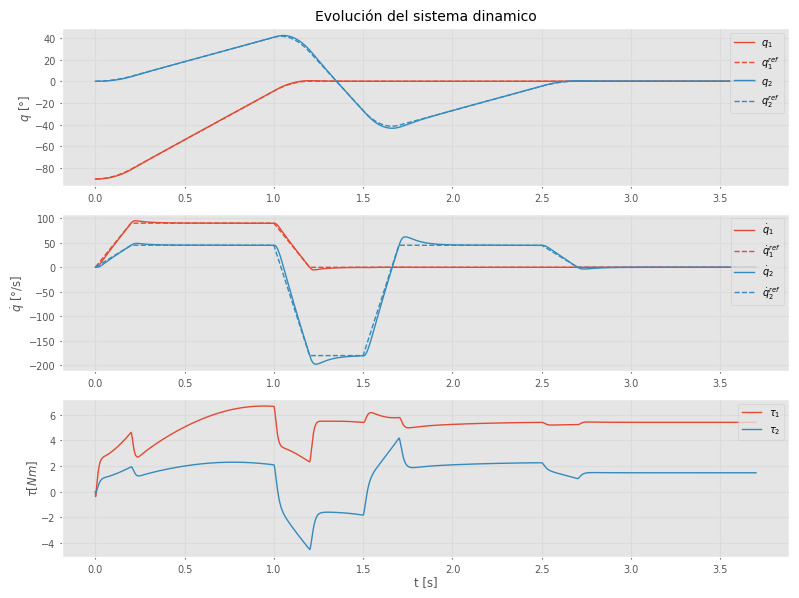

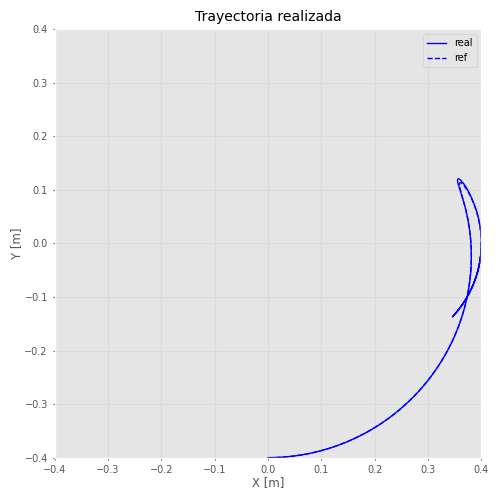

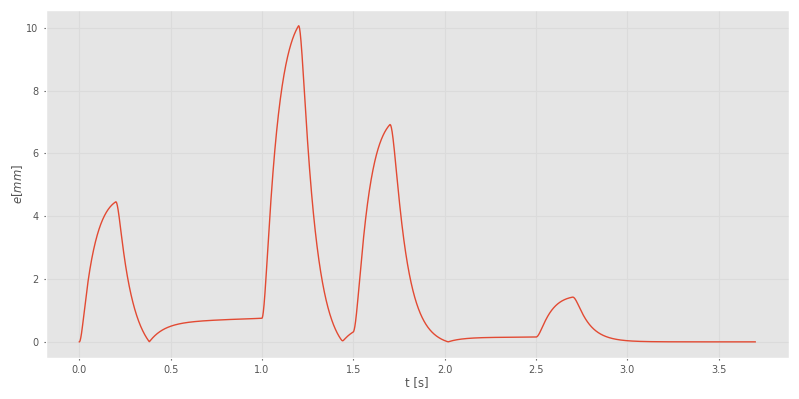

In [73]:
# Inicializo vectores para simulacion
u = np.zeros_like(dp.q_ref)
q = np.zeros_like(dp.q_ref)
qd = np.zeros_like(dp.qd_ref)

# La condición inicial sale de la primera muestra de las referencias
q[0,:] = dp.q_ref[0,:]
qd[0,:] = dp.qd_ref[0,:]

#Saturacion
umax = 10

#Deberia agregar el ZOH

# Realizo la simulación 

e = 0 # error acumulado

for idx in tqdm(range(1,len(dp.t_ref))):
    N = np.diag(np.r_[dp.links[0].G,dp.links[1].G])
    
    # Calculo la ley de control PID
    e += (dp.q_ref[idx]-q[idx-1])*dp.Ts
    u[idx,:] = N @ (Kp @ (dp.q_ref[idx]-q[idx-1]) + Kd @ (-qd[idx-1]) + Ki @ e)
    
    # Aplico la saturación en la acción de control
    u[idx,:] = np.clip(u[idx,:],-umax,umax)

    tg = dp.nofriction(coulomb=True, viscous=False).fdyn(dp.Ts, q[idx-1], qd0=qd[idx-1], Q=lambda r, t, q, qd: u[idx], solver_args=solver_kwargs)
    q[idx] = tg.q[-1,:]
    qd[idx] = tg.qd[-1,:]


dp.plot_sim(dp.t_ref,q,qd,dp.t_ref,u)

In [74]:
dp.animate_robot(q,frame_rate=12)

# Control PD+FF

In [75]:
def calc_pd_ff(omega_n, print_results=False):
    # Calculo las ganancias del control PD
    q_test = np.array([0, np.pi/2])  # Caso promedio de inercias 
    mbar = dp.inertia(q_test)

    B = np.diag(np.r_[dp.links[0].B, dp.links[1].B])
    N = np.diag(np.r_[dp.links[0].G, dp.links[1].G])

    Km = 1 
    Jef = np.array([[mbar[0,0], 0],
                    [0, mbar[1,1]]])
    Bef = B @ N**2 

    # --- SOPORTE PARA OMEGA_N MATRICIAL O VECTORIAL ---
    # Si pasan un vector [w1, w2], lo convierte a matriz diagonal. 
    # Si ya es una matriz, la usa directamente.
    if np.ndim(omega_n) == 1:
        Wn = np.diag(omega_n)
    else:
        Wn = omega_n

    # 1. Calculamos la inversa matricial de (Km * N) una sola vez
    inv_N_Km = np.linalg.inv(Km * N)

    # 2. Cálculo de Kp usando multiplicación matricial (@) para Wn^2
    Kp = (Wn @ Wn) @ Jef @ inv_N_Km

    # 3. Cálculo de Kd con raíz cuadrada matricial correcta (para la diagonal)
    dentro_raiz = Km * N @ Kp @ Jef
    raiz_matricial = np.diag(np.sqrt(np.diag(dentro_raiz)))
    Kd = (2 * raiz_matricial - Bef) @ inv_N_Km

    # 4. Cálculo de ganancias Feedforward (Kff)
    Kff1 = Jef @ inv_N_Km  # Compensación de inercia
    Kff2 = Bef @ inv_N_Km  # Compensación de fricción viscosa

    if print_results:
        print(f'Kp = \n{Kp}')
        print(f'Kd = \n{Kd}')
        print(f'Kff1 = \n{Kff1}')
        print(f'Kff2 = \n{Kff2}')
        print(f'Tiempo de muestreo = {dp.Ts*1000:.2f} ms')
        print(f'Pulsación de muestreo (ws) = {2*np.pi/dp.Ts:.2f} rad/s')
        print(f'Pulsación límite por muestreo = {2*np.pi/dp.Ts/20:.2f} rad/s')

    return Kp, Kd, Kff1, Kff2


In [76]:
Kp, Kd, Kff1, Kff2 = calc_pd_ff(omega_n=[200, 150],print_results=True)

Kp = 
[[74.44    0.    ]
 [ 0.     25.8975]]
Kd = 
[[0.7344 0.    ]
 [0.     0.3353]]
Kff1 = 
[[0.001861 0.      ]
 [0.       0.001151]]
Kff2 = 
[[0.01 0.  ]
 [0.   0.01]]
Tiempo de muestreo = 1.00 ms
Pulsación de muestreo (ws) = 6283.19 rad/s
Pulsación límite por muestreo = 314.16 rad/s


  0%|          | 0/3699 [00:00<?, ?it/s]

100%|██████████| 3699/3699 [00:17<00:00, 208.08it/s]


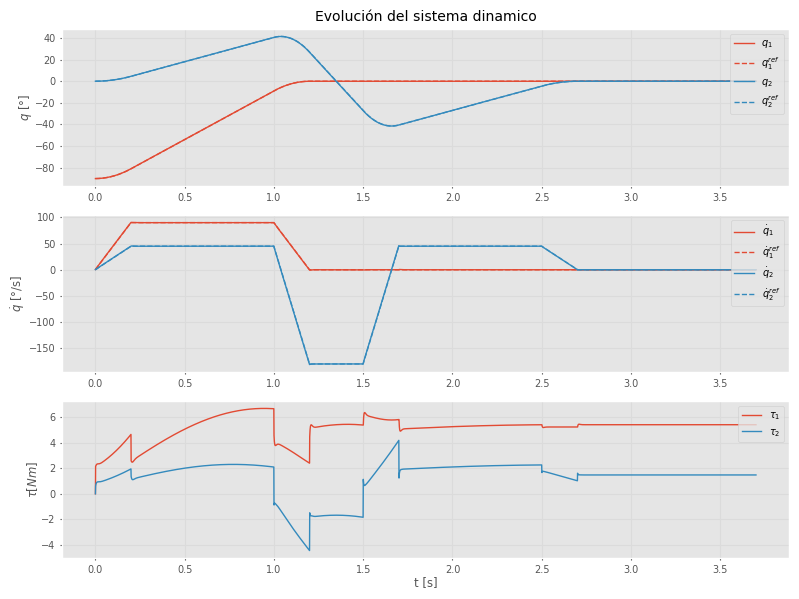

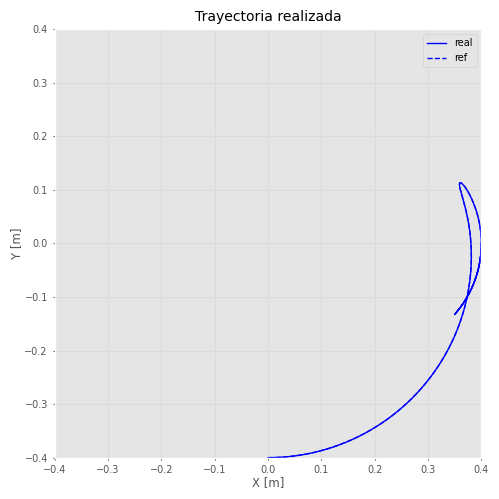

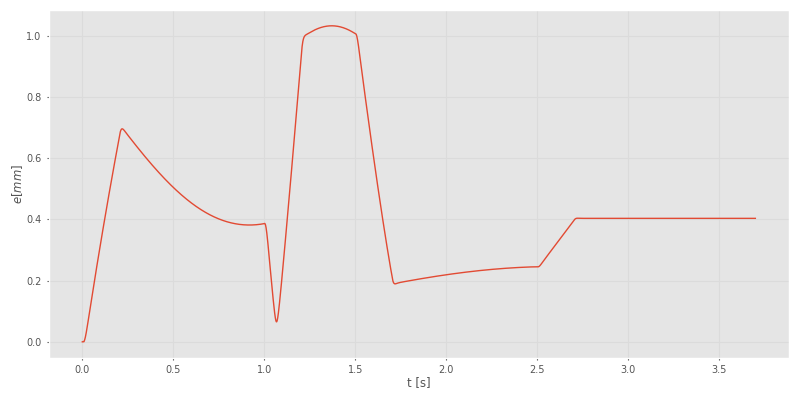

0.001


In [77]:
# Inicializo vectores para simulacion
u = np.zeros_like(dp.q_ref)
q = np.zeros_like(dp.q_ref)
qd = np.zeros_like(dp.qd_ref)

# La condición inicial sale de la primera muestra de las referencias
q[0,:] = dp.q_ref[0,:]
qd[0,:] = dp.qd_ref[0,:]

#Saturacion
umax = 10

#Deberia agregar el ZOH

# Realizo la simulación 
for idx in tqdm(range(1,len(dp.t_ref))):
  N = np.diag(np.r_[dp.links[0].G,dp.links[1].G])
  # Calculo la ley de control PD
  u[idx,:] = N @ (Kp @ (dp.q_ref[idx]-q[idx-1]) + Kd @ (dp.qd_ref[idx]-qd[idx-1]) + Kff1 @ (dp.qdd_ref[idx]) + Kff2 @ (dp.qd_ref[idx]))
  # Aplico la saturación en la acción de control
  u[idx,:] = np.clip(u[idx,:],-umax,umax)

  tg = dp.nofriction(coulomb=True, viscous=False).fdyn(dp.Ts, q[idx-1], qd0=qd[idx-1], Q=lambda r, t, q, qd: u[idx], solver_args=solver_kwargs)
  q[idx] = tg.q[-1,:]
  qd[idx] = tg.qd[-1,:]

dp.plot_sim(dp.t_ref,q,qd,dp.t_ref,u)

print(dp.Ts)

In [78]:
dp.animate_robot(q,frame_rate=12)